
# Snore vs Non‑Snore (Logistic Regression, **No YAMNet**)
- Keeps **data augmentation with noise** as in your original pipeline
- **Skips YAMNet** feature extractor
- Uses **MFCC statistics** (mean + std) and **Logistic Regression**
- Evaluates on **clean** and **noisy** test sets


In [ ]:

# Install dependencies
!pip install -q librosa soundfile noisereduce tqdm scikit-learn matplotlib kaggle


In [ ]:

# Mount Google Drive (optional but recommended if you want to cache datasets)
from google.colab import drive
drive.mount('/content/drive')

# Upload kaggle.json (only once per session)
from google.colab import files
files.upload()  # select kaggle.json

# Configure Kaggle
!mkdir -p ~/.kaggle
!cp -f kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


Mounted at /content/drive


Saving kaggle.json to kaggle.json


In [ ]:

# Create folders
!mkdir -p "/content/drive/MyDrive/snore_data"
!mkdir -p "/content/drive/MyDrive/noise_data"

# Download datasets
!kaggle datasets download tareqkhanemu/snoring -p "/content/drive/MyDrive/snore_data" --unzip
!kaggle datasets download mmoreaux/environmental-sound-classification-50 -p "/content/drive/MyDrive/noise_data" --unzip


Dataset URL: https://www.kaggle.com/datasets/tareqkhanemu/snoring
License(s): unknown
snoring.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset URL: https://www.kaggle.com/datasets/mmoreaux/environmental-sound-classification-50
License(s): CC-BY-NC-SA-4.0
environmental-sound-classification-50.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:

import os, random
import numpy as np
import librosa

# Paths (update if your folders differ)
SNORE_PATH      = "/content/drive/MyDrive/snore_data/Snoring Dataset/1"   # snore
NON_SNORE_PATH  = "/content/drive/MyDrive/snore_data/Snoring Dataset/0"   # non-snore
NOISE_PATH      = "/content/drive/MyDrive/noise_data/audio/audio"         # ESC-50 concatenated WAVs

snore_count = len([f for f in os.listdir(SNORE_PATH) if f.lower().endswith('.wav')])
nons_count  = len([f for f in os.listdir(NON_SNORE_PATH) if f.lower().endswith('.wav')])
noise_count = len([f for f in os.listdir(NOISE_PATH) if f.lower().endswith('.wav')])

print("Snore files:", snore_count)
print("Non-snore files:", nons_count)
print("Noise wavs:", noise_count)

assert snore_count>0 and nons_count>0 and noise_count>0, "Please verify dataset paths or Kaggle download."


Snore files: 500
Non-snore files: 500
Noise wavs: 2000


In [ ]:

# Collect available noise files
noise_files = [os.path.join(NOISE_PATH, f) for f in os.listdir(NOISE_PATH) if f.lower().endswith(".wav")]

def mix_audio_with_noise(audio, noise, snr_db=10):
    """Add noise to audio at target SNR (dB)."""
    if len(noise) < len(audio):
        reps = int(np.ceil(len(audio)/len(noise)))
        noise = np.tile(noise, reps)
    noise = noise[:len(audio)]
    eps = 1e-9
    rms_s = np.sqrt(np.mean(audio**2) + eps)
    rms_n = np.sqrt(np.mean(noise**2) + eps)
    k = rms_s / ((10**(snr_db/20)) * rms_n)
    return audio + k*noise

def load_with_optional_noise(file_path, add_noise=False, sr=16000, target_sec=3.0):
    """Load mono audio, pad/trim to length, optionally add random noise at random SNR."""
    y, _ = librosa.load(file_path, sr=sr, mono=True)
    target_len = int(sr*target_sec)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]
    if add_noise and noise_files:
        n, _ = librosa.load(random.choice(noise_files), sr=sr, mono=True)
        snr = random.uniform(5, 20)
        y = mix_audio_with_noise(y, n, snr_db=snr)
    return y.astype(np.float32)


In [ ]:

def extract_features(y, sr=16000, n_mfcc=40):
    """Return MFCC mean+std vector (size 80 by default)."""
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    return np.concatenate([mfcc.mean(axis=1), mfcc.std(axis=1)])

from sklearn.model_selection import train_test_split
from tqdm import tqdm

snore_files = [os.path.join(SNORE_PATH, f) for f in os.listdir(SNORE_PATH) if f.lower().endswith(".wav")]
non_files   = [os.path.join(NON_SNORE_PATH, f) for f in os.listdir(NON_SNORE_PATH) if f.lower().endswith(".wav")]

X_paths = snore_files + non_files
y_all   = np.array([1]*len(snore_files) + [0]*len(non_files))

X_tr_paths, X_te_paths, y_tr, y_te = train_test_split(
    X_paths, y_all, test_size=0.2, random_state=42, stratify=y_all
)

def features_from_paths(paths, add_noise=False):
    feats = []
    for p in tqdm(paths, desc=f"Extracting (add_noise={add_noise})"):
        y = load_with_optional_noise(p, add_noise=add_noise, sr=16000, target_sec=3.0)
        feats.append(extract_features(y, sr=16000, n_mfcc=40))
    return np.stack(feats)

# Augmented training, clean test
X_tr = features_from_paths(X_tr_paths, add_noise=True)
X_te = features_from_paths(X_te_paths, add_noise=False)
X_tr.shape, X_te.shape


Extracting (add_noise=False): 100%|██████████| 200/200 [00:34<00:00,  5.76it/s]


((800, 80), (200, 80))

In [ ]:

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
clf.fit(X_tr, y_tr)
print("Training complete.")


Training complete.


=== Clean Test ===
              precision    recall  f1-score   support

           0     0.7778    0.9800    0.8673       100
           1     0.9730    0.7200    0.8276       100

    accuracy                         0.8500       200
   macro avg     0.8754    0.8500    0.8474       200
weighted avg     0.8754    0.8500    0.8474       200

ROC-AUC: 0.9482


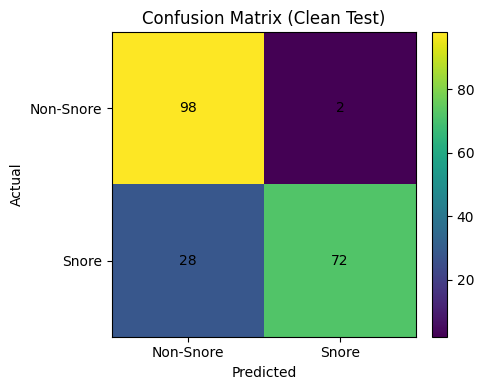

In [ ]:

from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Clean test
preds = clf.predict(X_te)
probs = clf.predict_proba(X_te)[:,1]

print("=== Clean Test ===")
print(classification_report(y_te, preds, digits=4))
print("ROC-AUC:", roc_auc_score(y_te, probs))

# Confusion matrix plot (matplotlib only, no seaborn, no explicit colors)
cm = confusion_matrix(y_te, preds)
fig = plt.figure(figsize=(5,4))
ax = fig.add_subplot(111)
im = ax.imshow(cm, interpolation='nearest')
ax.set_title('Confusion Matrix (Clean Test)')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_xticks([0,1]); ax.set_xticklabels(['Non-Snore','Snore'])
ax.set_yticks([0,1]); ax.set_yticklabels(['Non-Snore','Snore'])

# Annotate counts
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


In [ ]:

# Noisy test inference
X_te_noisy = features_from_paths(X_te_paths, add_noise=True)
preds_n = clf.predict(X_te_noisy)
probs_n = clf.predict_proba(X_te_noisy)[:,1]

print("=== Noisy Test ===")
print(classification_report(y_te, preds_n, digits=4))
print("ROC-AUC (noisy):", roc_auc_score(y_te, probs_n))


Extracting (add_noise=True): 100%|██████████| 200/200 [00:49<00:00,  4.05it/s]

=== Noisy Test ===
              precision    recall  f1-score   support

           0     0.7117    0.7900    0.7488       100
           1     0.7640    0.6800    0.7196       100

    accuracy                         0.7350       200
   macro avg     0.7379    0.7350    0.7342       200
weighted avg     0.7379    0.7350    0.7342       200

ROC-AUC (noisy): 0.7955
